## Clone repository

In [1]:
# # Clone the repository containing the project code
import sys
import os
repo_dir = 'cell-fuzzy-seg'
if not os.path.exists(repo_dir):
    !git clone --branch homolog https://github.com/Pedro-io/cell-fuzzy-seg.git
%cd {repo_dir}
sys.path.append(f"/content/{repo_dir}")

Cloning into 'cell-fuzzy-seg'...
remote: Enumerating objects: 476, done.
remote: Counting objects: 100% (275/275), done.
remote: Compressing objects: 100% (183/183), done.
remote: Total 476 (delta 116), reused 224 (delta 68), pack-reused 201 (from 2)
Receiving objects: 100% (476/476), 230.45 MiB | 20.52 MiB/s, done.
Resolving deltas: 100% (187/187), done.
Updating files: 100% (204/204), done.
/content/cell-fuzzy-seg


### Install Dependecies


In [2]:
!pip install -r requirements.txt

INFO: pip is looking at multiple versions of imagecodecs to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.4/213.4 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 94.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 85.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 76.5 MB/s eta 0:00:00:00:0100:01


In [3]:
from src.pipeline.steps.cellpose_step import CellposeStep
from src.pipeline.steps.rgba_step import RGBAStep
from src.io.output_writer import OutputWriter

Input directory with your images:

In [4]:
from src.data.load.monuseg_dataset import MonusegDataset

data = MonusegDataset(
  dataset_name="monuseg",
  config_key="monuseg_training"
  )

2026-07-14 12:00:09.950 | DEBUG    | src.data.load.monuseg_dataset:_get_file_pairs:96 - Getting file pairs from: image_dir=data_source/MoNuSegTrainingData/Tissue_Images, mask_dir=data_source/MoNuSegTrainingData/Annotations


In [5]:
class SimplePipeline:
    def __init__(self, steps):
        self.steps = steps

    def forward(self, data):
        for step in self.steps:
            data = step(data)
        return data

In [6]:
pipeline = SimplePipeline([
    CellposeStep(),
    RGBAStep()
])

100%|██████████| 1.15G/1.15G [00:06<00:00, 191MB/s] 
2026-07-14 12:00:20.937 | INFO     | src.pipeline.steps.cellpose_step:__init__:56 - [CellposeStep] Running on GPU


In [7]:
data = pipeline.forward(data[0])

2026-07-14 12:00:21.151 | DEBUG    | src.data.load.monuseg_dataset:_load_image:51 - Loading image: data_source/MoNuSegTrainingData/Tissue_Images/TCGA-18-5592-01Z-00-DX1.tif
2026-07-14 12:00:21.207 | DEBUG    | src.data.load.monuseg_dataset:_load_mask:73 - Loading mask: data_source/MoNuSegTrainingData/Annotations/TCGA-18-5592-01Z-00-DX1.xml
/usr/local/lib/python3.12/dist-packages/cellpose/dynamics.py:524: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),
2026-07-14 12:00:31.005 | DEBUG    | src.pipeline.steps.rgba_step:_build_rgba:73 - Building RGBA im

In [8]:
print(data.keys())

dict_keys(['id', 'image', 'ground_truth', 'meta', 'segmentation', 'flows', 'styles', 'rgba'])


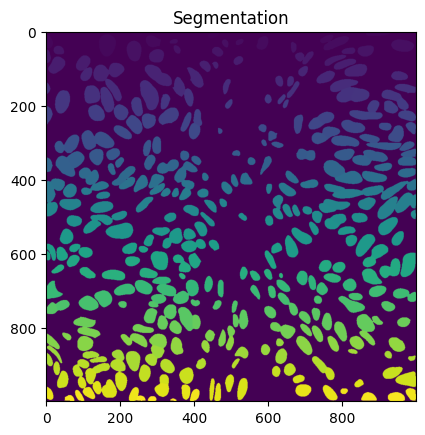

In [9]:
import matplotlib.pyplot as plt

plt.imshow(data["segmentation"])
plt.title("Segmentation")
plt.show()

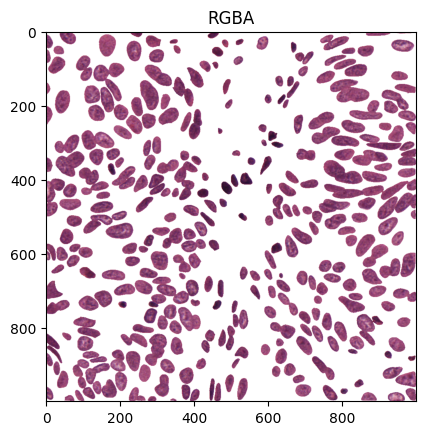

In [10]:
plt.imshow(data["rgba"])
plt.title("RGBA")
plt.show()

In [11]:
writer = OutputWriter("outputs")

writer.save_all(data)
writer.save_rgba(data["id"], data["rgba"])

In [12]:
print(data["image"].dtype, data["image"].min(), data["image"].max())

uint8 8 255


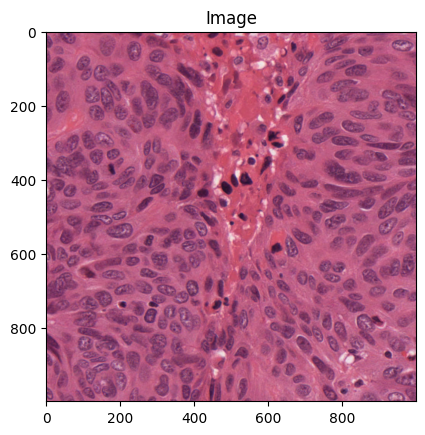

In [13]:
plt.imshow(data["image"])
plt.title("Image")
plt.show()

In [14]:
import matplotlib.pyplot as plt
from src.data.load.monuseg_dataset import MonusegDataset
from src.pipeline.steps.cellpose_step import CellposeStep
from src.pipeline.steps.rgba_step import RGBAStep

dataset = MonusegDataset(dataset_name="monuseg", config_key="monuseg_training")

sample = dataset[0]
print("ID:", sample["id"])
print("Imagem:", sample["image"].shape)
print("Ground truth:", sample["ground_truth"].shape)

2026-07-14 12:00:34.198 | DEBUG    | src.data.load.monuseg_dataset:_get_file_pairs:96 - Getting file pairs from: image_dir=data_source/MoNuSegTrainingData/Tissue_Images, mask_dir=data_source/MoNuSegTrainingData/Annotations
2026-07-14 12:00:34.200 | DEBUG    | src.data.load.monuseg_dataset:_load_image:51 - Loading image: data_source/MoNuSegTrainingData/Tissue_Images/TCGA-18-5592-01Z-00-DX1.tif
2026-07-14 12:00:34.241 | DEBUG    | src.data.load.monuseg_dataset:_load_mask:73 - Loading mask: data_source/MoNuSegTrainingData/Annotations/TCGA-18-5592-01Z-00-DX1.xml


ID: TCGA-18-5592-01Z-00-DX1
Imagem: (1000, 1000, 3)
Ground truth: (1000, 1000)


In [16]:
seg_step = CellposeStep()
rgba_step = RGBAStep()

data = {"image": sample["image"]}
data = seg_step.forward(data)
data = rgba_step.forward(data)

print("Chaves do resultado:", list(data.keys()))

2026-07-14 12:01:50.287 | INFO     | src.pipeline.steps.cellpose_step:__init__:56 - [CellposeStep] Running on GPU
2026-07-14 12:01:59.343 | DEBUG    | src.pipeline.steps.rgba_step:_build_rgba:73 - Building RGBA image: image shape (1000, 1000, 3), segmentation shape (1000, 1000)


Chaves do resultado: ['image', 'segmentation', 'flows', 'styles', 'rgba']


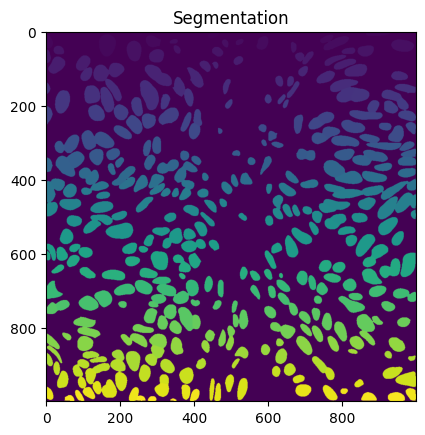

In [19]:
plt.imshow(data["segmentation"])
plt.title("Segmentation")
plt.show()

In [20]:
from src.data.load.monuseg_cellpose_dataset import MonusegCellposeDataset

dataset = MonusegCellposeDataset(dataset_name="monuseg", config_key="monuseg_training")

2026-07-14 12:11:47.120 | DEBUG    | src.data.load.monuseg_dataset:_get_file_pairs:96 - Getting file pairs from: image_dir=data_source/MoNuSegTrainingData/Tissue_Images, mask_dir=data_source/MoNuSegTrainingData/Annotations
2026-07-14 12:11:49.667 | INFO     | src.pipeline.steps.cellpose_step:__init__:56 - [CellposeStep] Running on GPU


In [37]:
print(list(dataset[0].keys()))

2026-07-14 12:43:55.751 | DEBUG    | src.data.load.monuseg_dataset:_load_image:51 - Loading image: data_source/MoNuSegTrainingData/Tissue_Images/TCGA-18-5592-01Z-00-DX1.tif
2026-07-14 12:43:55.791 | DEBUG    | src.data.load.monuseg_dataset:_load_mask:73 - Loading mask: data_source/MoNuSegTrainingData/Annotations/TCGA-18-5592-01Z-00-DX1.xml


['id', 'image', 'ground_truth', 'meta', 'cellpose_segmentation']


In [42]:
image = dataset[3]["image"]
cellpose_segmentation = dataset[3]["cellpose_segmentation"]
ground_truth = dataset[3]["ground_truth"]

2026-07-14 12:44:31.923 | DEBUG    | src.data.load.monuseg_dataset:_load_image:51 - Loading image: data_source/MoNuSegTrainingData/Tissue_Images/TCGA-38-6178-01Z-00-DX1.tif
2026-07-14 12:44:31.990 | DEBUG    | src.data.load.monuseg_dataset:_load_mask:73 - Loading mask: data_source/MoNuSegTrainingData/Annotations/TCGA-38-6178-01Z-00-DX1.xml
2026-07-14 12:44:44.152 | DEBUG    | src.data.load.monuseg_dataset:_load_image:51 - Loading image: data_source/MoNuSegTrainingData/Tissue_Images/TCGA-38-6178-01Z-00-DX1.tif
2026-07-14 12:44:44.224 | DEBUG    | src.data.load.monuseg_dataset:_load_mask:73 - Loading mask: data_source/MoNuSegTrainingData/Annotations/TCGA-38-6178-01Z-00-DX1.xml
2026-07-14 12:44:57.375 | DEBUG    | src.data.load.monuseg_dataset:_load_image:51 - Loading image: data_source/MoNuSegTrainingData/Tissue_Images/TCGA-38-6178-01Z-00-DX1.tif
2026-07-14 12:44:57.454 | DEBUG    | src.data.load.monuseg_dataset:_load_mask:73 - Loading mask: data_source/MoNuSegTrainingData/Annotations/TC

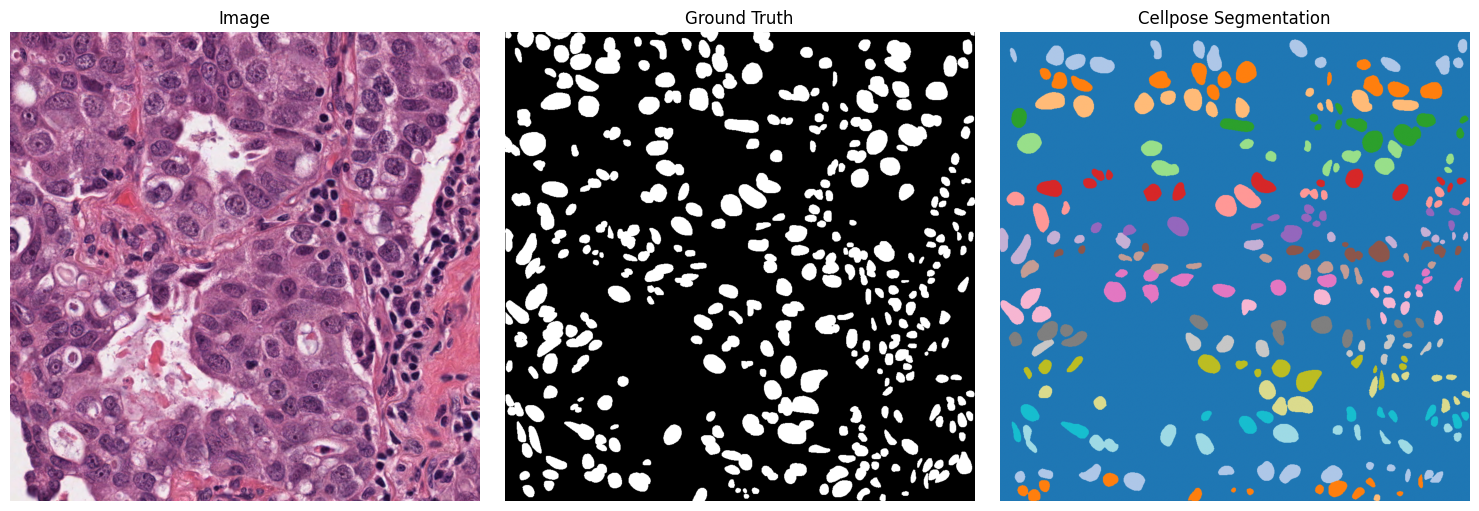

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Image")
axes[0].axis("off")

axes[1].imshow(ground_truth, cmap="gray")
axes[1].set_title("Ground Truth")
axes[1].axis("off")

axes[2].imshow(cellpose_segmentation, cmap="tab20")
axes[2].set_title("Cellpose Segmentation")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [44]:
print("image dtype:", image.dtype, "min/max:", image.min(), image.max())
print("ground_truth dtype:", ground_truth.dtype, "min/max:", ground_truth.min(), ground_truth.max())
print("cellpose_segmentation dtype:", cellpose_segmentation.dtype, "min/max:", cellpose_segmentation.min(), cellpose_segmentation.max())

image dtype: uint8 min/max: 1 255
ground_truth dtype: uint8 min/max: 0 1
cellpose_segmentation dtype: uint8 min/max: 0 255


In [45]:
import numpy as np
import cellpose

masks = np.asarray(cellpose_segmentation)
if masks.dtype != np.int32 and masks.dtype != np.int64:
    masks = masks.astype(np.int32, copy=False)

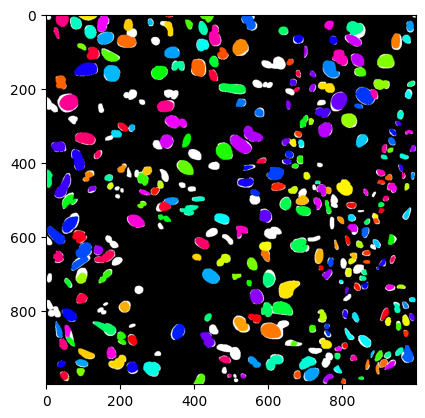

In [46]:
overlay = cellpose.plot.mask_overlay(ground_truth, masks)
plt.imshow(overlay)
plt.show()